# Perceptron code implementation.

In [1]:
import torch # libreria para hacer modelos de redes nueronales nombre especifo pytorch

import numpy as np
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

(800, 2) (800,) (200, 2) (200,)


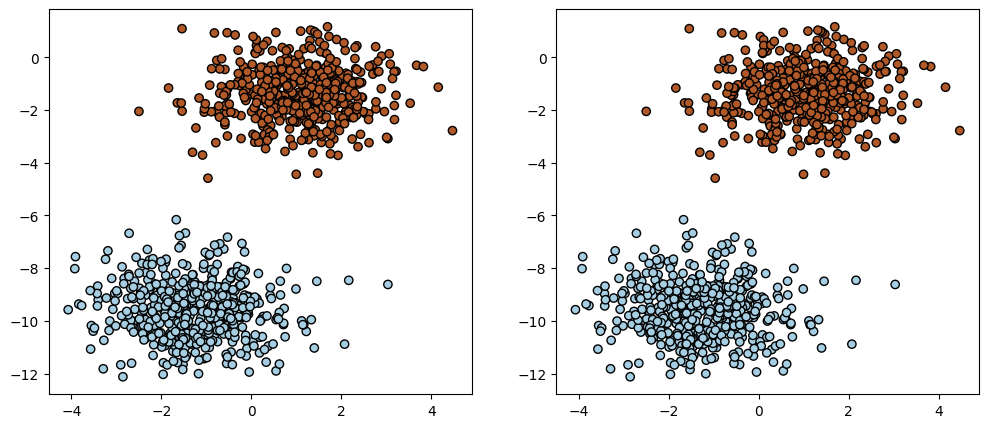

In [2]:
X, y = make_blobs(n_samples=1000, n_features=2, centers=2, cluster_std=1.05, random_state=2)

X_train, X_test, y_train, y_test = train_test_split( X , y , test_size = 0.20, random_state = 2)
print ( X_train.shape, y_train.shape, X_test.shape, y_test.shape )

_, axes = plt.subplots(1,2, figsize=(12,5))

# plot everythig
axes[0].scatter( X[:,0] , X[:,1] , c = y , edgecolors='k', cmap = 'Paired')
axes[1].scatter( X_train[:,0] , X_train[:,1] , c = y_train , edgecolors='k', cmap = 'Paired')
axes[1].scatter( X_test[:,0] , X_test[:,1] , c = y_test , edgecolors='k', cmap = 'Paired')


## Perceptron code

In [5]:
def activation(cond, x_1, x_2):
    return (cond * x_1) + (~(cond) * x_2) # virgulilla es not funciona como bool

class Perceptron():
    def __init__(self, num_features):
        self.num_features = num_features
        self.weights = torch.zeros(num_features, 1, requires_grad=False)# torch.zeros: crea un vertor lleno de 0s
        self.bias = torch.zeros(1)

    def forward(self, X): #es la funcion predict
        linear = torch.add(torch.mm(X, self.weights), self.bias)# funcion lineal = x , la pendiente m
        predictions = activation(linear > 0., 1, 0).float() # Step
        return predictions

    def backward(self, x, y): #es la funcion que calcula el error predecir errores con x y calula errores con y
        predictions = self.forward(x)
        errors = y - predictions
        return errors

    def train(self, x, y, epochs):
        for epoch in range(epochs):
            for i in range(y.size()[0]):
                errors = self.backward(x[i].view(1, self.num_features), y[i]).view(-1) #Calculo de errores - view(-1): datos de los errores calculados
                self.weights += (errors * x[i]).view(self.num_features, 1)#Actualizar el valor de los pesos es como hacer el peso en el gradiente
                self.bias += errors #POr que se hace en este punto el calculo de actualizacion de los pesos? todo esta en la forma de como nos da la derivada de cuando optimizamos usando la funcion de costo del mine

    def evaluate(self, x, y):
        predictions = self.forward(x).view(-1)
        accuracy = torch.sum(predictions == y).float() / y.size()[0] #comparacion de las predicciones con los valores reales y se convierte a float donde haya acierto da 1 y si hay fallo da 0 # tamano de nuemro de muestras
        return accuracy

In [6]:
ppn = Perceptron(num_features=2)

X_train_tensor = torch.from_numpy( X_train ).type(torch.FloatTensor).to('cpu')
y_train_tensor = torch.from_numpy( y_train ).type(torch.FloatTensor).to('cpu')

ppn.train( X_train_tensor , y_train_tensor , epochs=20)

In [7]:
print('Model parameters:')
print('  Weights: %s' % ppn.weights)
print('  Bias: %s' % ppn.bias)

Model parameters:
  Weights: tensor([[3.9296],
        [4.7201]])
  Bias: tensor([27.])


In [8]:
X_test_tensor = torch.from_numpy( X_test ).type(torch.FloatTensor).to('cpu')
y_test_tensor = torch.from_numpy( y_test ).type(torch.FloatTensor).to('cpu')

test_acc = ppn.evaluate( X_test_tensor , y_test_tensor )
print('Test set accuracy: %.2f%%' % (test_acc*100))

Test set accuracy: 100.00%


## Plot everything

In [9]:
# Min max values for the decision bounding grid
h_min, h_max = X_test[:, 0].min() , X_test[:,0].max()
v_min, v_max = X_test[:, 0].min() , X_test[:, 1].max()

# Create the grid
h_grid, v_grid = np.meshgrid(np.arange( h_min , h_max , 200), np.arange( v_min , v_max , 200))

# Predict
to_predict = torch.from_numpy(np.c_[h_grid.ravel(), v_grid.ravel()]).type(torch.FloatTensor).to('cpu')#contruccion del array con torch
predictions = ppn.forward( to_predict )
predictions = predictions.numpy().reshape(h_grid.shape) # convertir de tensor a arreglo de numpy

[]

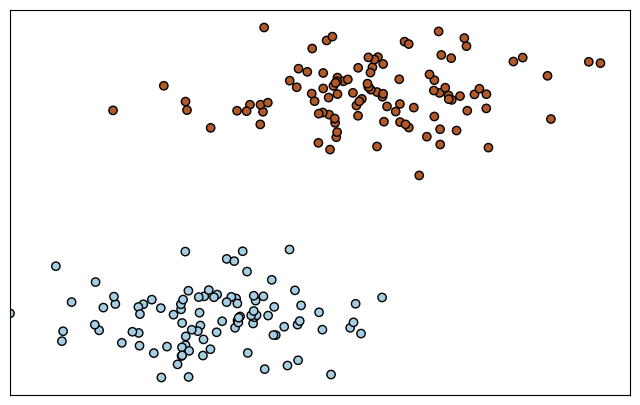

In [10]:
# Draw everything
_, ax = plt.subplots (figsize=(8,5))
ax.pcolormesh( h_grid , v_grid , predictions , cmap = 'Paired')
#ax.contour(  _ , _ , predictions, colors=['k', 'k', 'k'], linestyles=['--', '--', '--'], levels=[0, 1, 2])

# show the scatter
ax.scatter ( X_test[:, 0] , X_test[: , 1] ,  c = y_test , edgecolors='k', cmap='Paired')

ax.set_xticks(())
ax.set_yticks(())